SUPRIYA K 
24BAD118
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perim

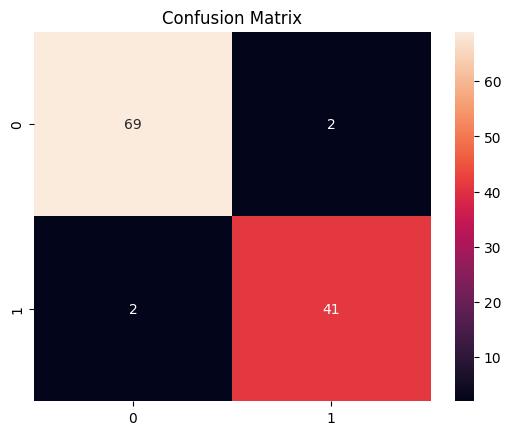

Misclassified samples: 4


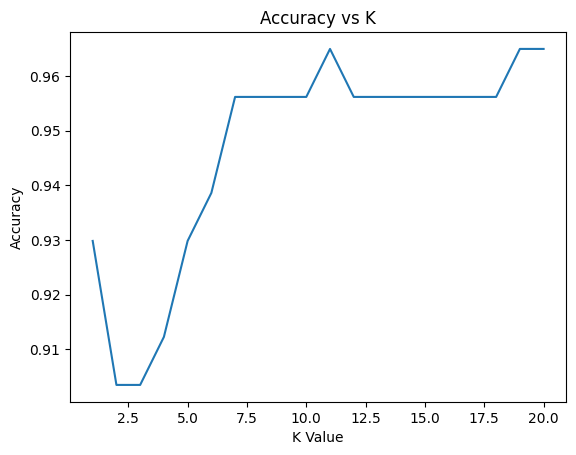

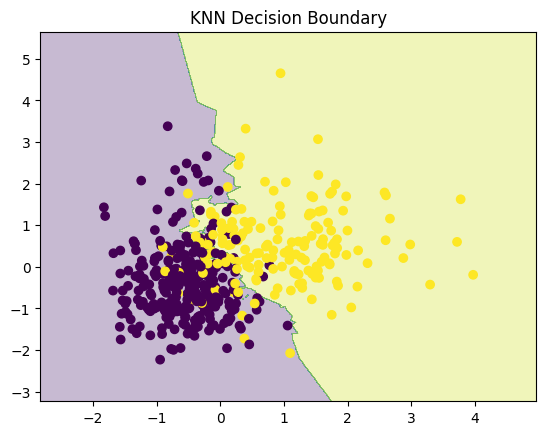

In [3]:
print("SUPRIYA K \n24BAD118")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
df = pd.read_csv("breast-cancer.csv")
print(df.head())
print(df.info())
print(df.isnull().sum())
X = df[['radius_mean','texture_mean',
        'perimeter_mean','area_mean','smoothness_mean']]
y = df['diagnosis']
le = LabelEncoder()
y = le.fit_transform(y)
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
accuracy_list = []
for k in range(1,21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy_list.append(accuracy_score(y_test, y_pred))
best_k = np.argmax(accuracy_list)+1
print("Best K:", best_k)
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()
misclassified = np.where(y_test != y_pred)
print("Misclassified samples:", len(misclassified[0]))

plt.plot(range(1,21), accuracy_list)
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.show()

# Using only two features
X2 = df[['radius_mean','texture_mean']]
X2 = scaler.fit_transform(X2)

X_train,X_test,y_train,y_test = train_test_split(
    X2,y,test_size=0.2,random_state=42)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train,y_train)

from matplotlib.colors import ListedColormap

x_min,x_max = X_train[:,0].min()-1,X_train[:,0].max()+1
y_min,y_max = X_train[:,1].min()-1,X_train[:,1].max()+1

xx,yy=np.meshgrid(np.arange(x_min,x_max,0.01),
                  np.arange(y_min,y_max,0.01))

Z=model.predict(np.c_[xx.ravel(),yy.ravel()])
Z=Z.reshape(xx.shape)

plt.contourf(xx,yy,Z,alpha=0.3)
plt.scatter(X_train[:,0],X_train[:,1],c=y_train)
plt.title("KNN Decision Boundary")
plt.show()

SUPRIYA K 
24BAD118
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  


C:\Users\supri\AppData\Local\Temp\ipykernel_21680\2471919682.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


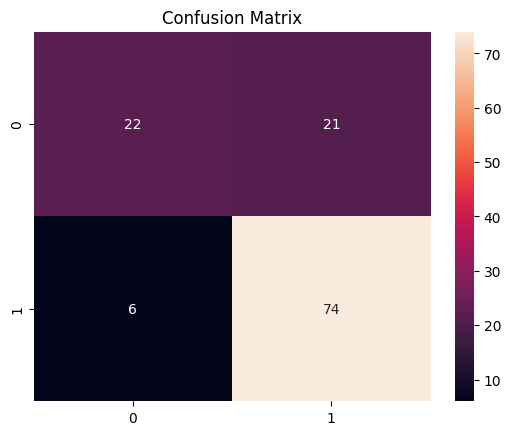

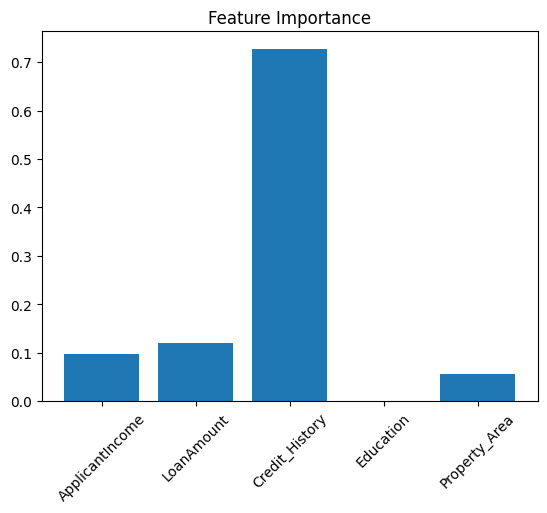

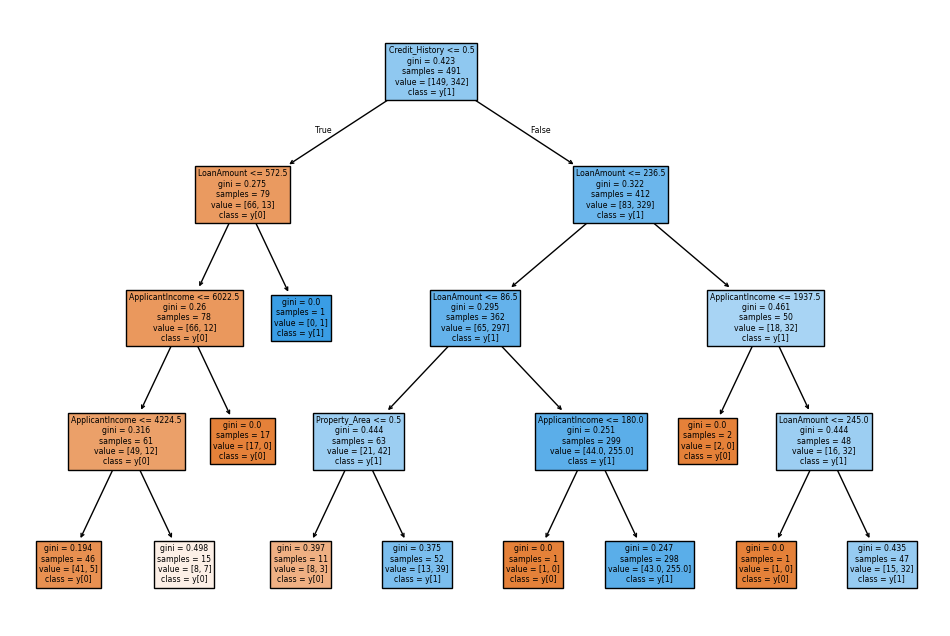

In [6]:
print("SUPRIYA K \n24BAD118")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("train_u6lujuX_CVtuZ9i (1).csv")

print(df.head())
print(df.isnull().sum())

df.fillna(method='ffill', inplace=True)

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

X = df[['ApplicantIncome','LoanAmount',
        'Credit_History','Education','Property_Area']]

y = df['Loan_Status']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)

tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train,y_train)

y_pred = tree.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix")
plt.show()

importance = tree.feature_importances_

plt.bar(X.columns, importance)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12,8))
plot_tree(tree,
          feature_names=X.columns,
          class_names=True,
          filled=True)
plt.show()

train_acc=[]
test_acc=[]

depth_range=range(1,15)

for d in depth_range:
    model=DecisionTreeClassifier(max_depth=d)
    model.fit(X_train,y_train)

    train_acc.append(model.score(X_train,y_train))
    test_acc.append(model.score(X_test,y_test))

